# Visualize Augmentation Results

This notebook is for understanding augmentation outcomes, not just inspecting saved CSV files.

It loads saved augmentation artifacts across datasets and variants, then visualizes:
- baseline vs augmented metrics
- augmentation gains by dataset and model
- class counts at each major stage
- synthetic kind mix per emotion
- per-class precision, recall, F1, and support
- best-model confusion matrices


In [29]:
from functools import lru_cache
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

plt.style.use('ggplot')
sns.set_theme(style='whitegrid')

CWD = Path.cwd().resolve()
REPO_ROOT = CWD if (CWD / 'pyproject.toml').exists() else next(
    path for path in [CWD, *CWD.parents] if (path / 'pyproject.toml').exists()
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from feature_augmentation.common import resolve_augmentation_artifact_dir

AUGMENTATION_DIR = REPO_ROOT / 'feature_augmentation' / 'mean_std_oversampling'
DEFAULT_ARTIFACT_DIR = AUGMENTATION_DIR / 'artifacts'
RUN_NAME = 'feature_aug_noaug_v1'
WITH_XXX_DIR = resolve_augmentation_artifact_dir(REPO_ROOT, include_xxx=True, use_variant_dirs=True, run_name=RUN_NAME)
WITHOUT_XXX_DIR = resolve_augmentation_artifact_dir(REPO_ROOT, include_xxx=False, use_variant_dirs=True, run_name=RUN_NAME)

ARTIFACT_GROUPS = {}
if WITH_XXX_DIR.exists():
    ARTIFACT_GROUPS['with_xxx'] = WITH_XXX_DIR
if WITHOUT_XXX_DIR.exists():
    ARTIFACT_GROUPS['without_xxx'] = WITHOUT_XXX_DIR
if not ARTIFACT_GROUPS and DEFAULT_ARTIFACT_DIR.exists():
    ARTIFACT_GROUPS['current'] = DEFAULT_ARTIFACT_DIR

FOCUS_DATASET = None
FOCUS_GROUP = None
SAVE_COMPARISON_CSV = True

for group_name, artifact_dir in ARTIFACT_GROUPS.items():
    print(f'{group_name}: {artifact_dir} | exists={artifact_dir.exists()}')


with_xxx: /cluster/home/bekadb/Speech-Emotion-Recognition/feature_augmentation/mean_std_oversampling/artifacts/feature_aug_noaug_v1/with_xxx | exists=True
without_xxx: /cluster/home/bekadb/Speech-Emotion-Recognition/feature_augmentation/mean_std_oversampling/artifacts/feature_aug_noaug_v1/without_xxx | exists=True


In [30]:
@lru_cache(maxsize=None)
def _load_json(path_str: str) -> dict:
    return json.loads(Path(path_str).read_text(encoding='utf-8'))


def read_csv_if_exists(path_str: str | None) -> pd.DataFrame:
    if not path_str:
        return pd.DataFrame()
    path = Path(path_str)
    if not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path)


def best_metric_row(meta: dict, stage: str) -> dict:
    if stage not in {'baseline', 'augmented'}:
        raise ValueError(f'Unsupported stage: {stage}')

    single_key = 'best_baseline_metrics' if stage == 'baseline' else 'best_augmented_metrics'
    rows_key = 'baseline_model_metrics' if stage == 'baseline' else 'augmented_model_metrics'
    model_key = 'best_baseline_model' if stage == 'baseline' else 'best_augmented_model'

    if isinstance(meta.get(single_key), dict) and meta[single_key]:
        row = dict(meta[single_key])
        if 'accuracy' not in row and 'accuracy_mean' in row:
            row['accuracy'] = row.get('accuracy_mean')
        if 'precision_weighted' not in row and 'precision_weighted_mean' in row:
            row['precision_weighted'] = row.get('precision_weighted_mean')
        if 'recall_weighted' not in row and 'recall_weighted_mean' in row:
            row['recall_weighted'] = row.get('recall_weighted_mean')
        if 'f1_weighted' not in row and 'f1_weighted_mean' in row:
            row['f1_weighted'] = row.get('f1_weighted_mean')
        if 'f1_macro' not in row and 'f1_macro_mean' in row:
            row['f1_macro'] = row.get('f1_macro_mean')
        return row

    best_model = meta.get(model_key)
    for row in meta.get(rows_key, []):
        if row.get('model') == best_model:
            return row

    rows = meta.get(rows_key, [])
    if rows:
        return max(rows, key=lambda row: row.get('f1_macro', float('-inf')))
    return {}


def stage_total_from_fold_counts(meta: dict, stage_name: str, reducer: str = 'mean') -> float | None:
    artifact_files = meta.get('artifact_files', {})
    fold_counts_df = read_csv_if_exists(artifact_files.get('fold_class_counts'))
    if fold_counts_df.empty:
        return None
    stage_df = fold_counts_df[fold_counts_df['stage'] == stage_name].copy()
    if stage_df.empty:
        return None
    per_fold = stage_df.groupby('fold', dropna=False)['class_count'].sum()
    if per_fold.empty:
        return None
    if reducer == 'sum':
        return float(per_fold.sum())
    return float(per_fold.mean())


def synthetic_rows_added_from_summary(meta: dict) -> int | None:
    artifact_files = meta.get('artifact_files', {})
    summary_df = read_csv_if_exists(artifact_files.get('augmentation_summary_full_data'))
    if summary_df.empty or 'synthetic_added' not in summary_df.columns:
        return None
    return int(summary_df['synthetic_added'].fillna(0).sum())


def support_columns(meta: dict) -> dict[str, int]:
    artifact_files = meta.get('artifact_files', {})
    class_counts_df = read_csv_if_exists(artifact_files.get('class_counts'))
    if class_counts_df.empty:
        return {}

    rows = {}
    for stage_name in ['train_reference', 'test_reference', 'synthetic_only', 'train_augmented']:
        stage_df = class_counts_df[class_counts_df['stage'] == stage_name]
        for _, row in stage_df.iterrows():
            label = str(row[meta.get('target_col', 'emotion')])
            rows[f'{stage_name}_support_{label}'] = int(row['class_count'])
    return rows


def find_meta_paths(artifact_dir: Path) -> list[Path]:
    return sorted(artifact_dir.rglob('*_run_metadata.json'))


def find_meta_path(dataset_key: str, group_name: str) -> Path:
    artifact_dir = ARTIFACT_GROUPS[group_name]
    matches = [path for path in find_meta_paths(artifact_dir) if path.name == f'{dataset_key}_run_metadata.json']
    if not matches:
        raise FileNotFoundError(f'Missing metadata for {dataset_key} | {group_name} under {artifact_dir}')
    if len(matches) > 1:
        raise RuntimeError(f'Multiple metadata files found for {dataset_key} | {group_name}: {matches}')
    return matches[0]


def load_group_summary(group_name: str, artifact_dir: Path) -> pd.DataFrame:
    rows = []
    for meta_path in find_meta_paths(artifact_dir):
        meta = json.loads(meta_path.read_text(encoding='utf-8'))
        baseline_best = best_metric_row(meta, 'baseline')
        augmented_best = best_metric_row(meta, 'augmented')
        train_rows_reference = meta.get('train_rows_reference', meta.get('train_rows_before_augmentation'))
        if train_rows_reference is None:
            train_rows_reference = stage_total_from_fold_counts(meta, 'train_reference', reducer='mean')
        test_rows_reference = meta.get('test_rows_reference')
        if test_rows_reference is None:
            test_rows_reference = stage_total_from_fold_counts(meta, 'test_reference', reducer='mean')
        train_rows_after_augmentation = meta.get('train_rows_after_augmentation')
        if train_rows_after_augmentation is None:
            train_rows_after_augmentation = stage_total_from_fold_counts(meta, 'train_augmented', reducer='mean')
        synthetic_rows_added = meta.get('synthetic_rows_added')
        if synthetic_rows_added is None:
            synthetic_rows_added = synthetic_rows_added_from_summary(meta)

        row = {
            'group': group_name,
            'dataset_key': meta['dataset_key'],
            'rows_loaded': meta.get('rows_loaded'),
            'rows_after_filter': meta.get('rows_after_filter'),
            'rows_used': meta.get('rows_used'),
            'train_rows_reference': train_rows_reference,
            'test_rows_reference': test_rows_reference,
            'train_rows_after_augmentation': train_rows_after_augmentation,
            'synthetic_rows_added': synthetic_rows_added,
            'feature_columns_used': meta.get('feature_columns_used'),
            'best_baseline_model': meta.get('best_baseline_model'),
            'best_augmented_model': meta.get('best_augmented_model'),
            'baseline_accuracy': baseline_best.get('accuracy', meta.get('baseline_accuracy')),
            'baseline_precision_weighted': baseline_best.get('precision_weighted'),
            'baseline_recall_weighted': baseline_best.get('recall_weighted'),
            'baseline_f1_weighted': baseline_best.get('f1_weighted', meta.get('baseline_f1_weighted')),
            'baseline_f1_macro': baseline_best.get('f1_macro', meta.get('baseline_f1_macro')),
            'augmented_accuracy': augmented_best.get('accuracy', meta.get('augmented_accuracy')),
            'augmented_precision_weighted': augmented_best.get('precision_weighted'),
            'augmented_recall_weighted': augmented_best.get('recall_weighted'),
            'augmented_f1_weighted': augmented_best.get('f1_weighted', meta.get('augmented_f1_weighted')),
            'augmented_f1_macro': augmented_best.get('f1_macro', meta.get('augmented_f1_macro')),
            'artifact_dir': meta.get('artifact_dir'),
            'meta_path': str(meta_path),
        }
        row.update(support_columns(meta))
        rows.append(row)

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    numeric_columns = [
        'rows_loaded',
        'rows_after_filter',
        'rows_used',
        'train_rows_reference',
        'test_rows_reference',
        'train_rows_after_augmentation',
        'synthetic_rows_added',
        'feature_columns_used',
        'baseline_accuracy',
        'baseline_precision_weighted',
        'baseline_recall_weighted',
        'baseline_f1_weighted',
        'baseline_f1_macro',
        'augmented_accuracy',
        'augmented_precision_weighted',
        'augmented_recall_weighted',
        'augmented_f1_weighted',
        'augmented_f1_macro',
    ]
    for col in numeric_columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    df['accuracy_delta'] = df['augmented_accuracy'] - df['baseline_accuracy']
    df['precision_weighted_delta'] = df['augmented_precision_weighted'] - df['baseline_precision_weighted']
    df['recall_weighted_delta'] = df['augmented_recall_weighted'] - df['baseline_recall_weighted']
    df['f1_weighted_delta'] = df['augmented_f1_weighted'] - df['baseline_f1_weighted']
    df['f1_macro_delta'] = df['augmented_f1_macro'] - df['baseline_f1_macro']
    return df.sort_values(['group', 'f1_macro_delta'], ascending=[True, False], ignore_index=True)


def load_model_delta_table(group_name: str, artifact_dir: Path) -> pd.DataFrame:
    rows = []
    for meta_path in find_meta_paths(artifact_dir):
        meta = json.loads(meta_path.read_text(encoding='utf-8'))
        for row in meta.get('model_metric_deltas', []):
            current = {'group': group_name, 'dataset_key': meta['dataset_key']}
            current.update(row)
            rows.append(current)
    return pd.DataFrame(rows)


def build_pairwise_comparison(summary_df: pd.DataFrame, left_group: str, right_group: str) -> pd.DataFrame:
    left_df = summary_df[summary_df['group'] == left_group].copy()
    right_df = summary_df[summary_df['group'] == right_group].copy()
    if left_df.empty or right_df.empty:
        return pd.DataFrame()

    merged = left_df.merge(
        right_df,
        on='dataset_key',
        suffixes=(f'|{left_group}', f'|{right_group}'),
    )
    merged[f'augmented_f1_macro_change_{right_group}_minus_{left_group}'] = (
        merged[f'augmented_f1_macro|{right_group}'] - merged[f'augmented_f1_macro|{left_group}']
    )
    merged[f'augmentation_gain_change_{right_group}_minus_{left_group}'] = (
        merged[f'f1_macro_delta|{right_group}'] - merged[f'f1_macro_delta|{left_group}']
    )
    return merged


def load_artifact_meta(dataset_key: str, group_name: str) -> dict:
    meta_path = find_meta_path(dataset_key, group_name)
    return json.loads(meta_path.read_text(encoding='utf-8'))


def load_stage_counts(dataset_key: str, group_name: str) -> pd.DataFrame:
    meta = load_artifact_meta(dataset_key, group_name)
    artifact_files = meta.get('artifact_files', {})

    class_counts_df = read_csv_if_exists(artifact_files.get('class_counts'))
    fold_counts_df = read_csv_if_exists(artifact_files.get('fold_class_counts'))
    label_col = meta.get('target_col', 'emotion')

    frames = []
    if not class_counts_df.empty:
        keep_stages = ['raw_loaded', 'filtered', 'model_ready']
        frames.append(class_counts_df[class_counts_df['stage'].isin(keep_stages)].copy())

    if not fold_counts_df.empty:
        keep_stages = ['train_reference', 'test_reference', 'synthetic_only', 'train_augmented']
        averaged_fold_df = (
            fold_counts_df[fold_counts_df['stage'].isin(keep_stages)]
            .groupby(['stage', label_col], as_index=False)['class_count']
            .mean()
        )
        averaged_fold_df['class_count'] = averaged_fold_df['class_count'].round().astype(int)
        frames.append(averaged_fold_df)

    if not frames:
        return pd.DataFrame(columns=['stage', label_col, 'class_count'])

    return pd.concat(frames, ignore_index=True)


def load_synthetic_kind_counts(dataset_key: str, group_name: str) -> pd.DataFrame:
    meta = load_artifact_meta(dataset_key, group_name)
    return read_csv_if_exists(meta.get('artifact_files', {}).get('synthetic_kind_counts'))


def load_reports(dataset_key: str, group_name: str) -> pd.DataFrame:
    meta = load_artifact_meta(dataset_key, group_name)
    return read_csv_if_exists(meta.get('artifact_files', {}).get('classification_reports'))


def load_confusions(dataset_key: str, group_name: str) -> pd.DataFrame:
    meta = load_artifact_meta(dataset_key, group_name)
    return read_csv_if_exists(meta.get('artifact_files', {}).get('confusion_matrices'))


In [31]:
summary_frames = []
delta_frames = []

for group_name, artifact_dir in ARTIFACT_GROUPS.items():
    if artifact_dir.exists():
        summary_frames.append(load_group_summary(group_name, artifact_dir))
        delta_frames.append(load_model_delta_table(group_name, artifact_dir))

summary_df = pd.concat(summary_frames, ignore_index=True) if summary_frames else pd.DataFrame()
model_delta_df = pd.concat(delta_frames, ignore_index=True) if delta_frames else pd.DataFrame()

if summary_df.empty:
    print('No augmentation artifact metadata found.')
else:
    display(summary_df)


,group,dataset_key,rows_loaded,rows_after_filter,rows_used,train_rows_reference,test_rows_reference,train_rows_after_augmentation,synthetic_rows_added,feature_columns_used,...,augmented_recall_weighted,augmented_f1_weighted,augmented_f1_macro,artifact_dir,meta_path,accuracy_delta,precision_weighted_delta,recall_weighted_delta,f1_weighted_delta,f1_macro_delta
0,with_xxx,bert,9887,9887,9887,7909.6,1977.4,14032.6,4620,768,...,0.420900,0.419887,0.408222,/cluster/home/bekadb/Speech-Emotion-Recognitio...,/cluster/home/bekadb/Speech-Emotion-Recognitio...,0.011150,-0.004331,0.011150,0.015311,0.024344
1,with_xxx,ssl_wav2vec,9887,9887,9887,7909.6,1977.4,14032.6,4620,1539,...,0.365571,0.357781,0.339024,/cluster/home/bekadb/Speech-Emotion-Recognitio...,/cluster/home/bekadb/Speech-Emotion-Recognitio...,0.000379,-0.014074,0.000379,0.008579,0.018184
2,with_xxx,ssl_hubert,9887,9887,9887,7909.6,1977.4,14032.6,4620,1539,...,0.364079,0.355144,0.338324,/cluster/home/bekadb/Speech-Emotion-Recognitio...,/cluster/home/bekadb/Speech-Emotion-Recognitio...,0.003375,0.004684,0.003375,0.011250,0.017333
3,with_xxx,representations,9887,9887,9887,7909.6,1977.4,14032.6,4620,136,...,0.335059,0.322992,0.306263,/cluster/home/bekadb/Speech-Emotion-Recognitio...,/cluster/home/bekadb/Speech-Emotion-Recognitio...,-0.008705,-0.016481,-0.008705,-0.001218,0.009980
4,with_xxx,prosody_energy,9887,9887,9887,7909.6,1977.4,14032.6,4620,8,...,0.280120,0.268330,0.245687,/cluster/home/bekadb/Speech-Emotion-Recognitio...,/cluster/home/bekadb/Speech-Emotion-Recognitio...,-0.000277,0.001755,-0.000277,0.004158,0.008730
5,with_xxx,rhythm_pauses,9887,9887,9887,7909.6,1977.4,14032.6,4620,6,...,0.235034,0.224883,0.201976,/cluster/home/bekadb/Speech-Emotion-Recognitio...,/cluster/home/bekadb/Speech-Emotion-Recognitio...,-0.018407,-0.005050,-0.018407,-0.002622,0.007139
6,with_xxx,tonality,9887,9887,9887,7909.6,1977.4,14032.6,4620,91,...,0.255038,0.237771,0.207215,/cluster/home/bekadb/Speech-Emotion-Recognitio...,/cluster/home/bekadb/Speech-Emotion-Recognitio...,-0.016099,-0.012346,-0.016099,-0.000818,0.004424
7,with_xxx,prosody_pitch,9887,9887,9887,7909.6,1977.4,14032.6,4620,11,...,0.265484,0.253531,0.231352,/cluster/home/bekadb/Speech-Emotion-Recognitio...,/cluster/home/bekadb/Speech-Emotion-Recognitio...,-0.012955,-0.012678,-0.012955,-0.003784,0.004315
8,with_xxx,mfcc_raw,9887,9887,9887,7909.6,1977.4,14032.6,4620,1150,...,0.344077,0.328739,0.323370,/cluster/home/bekadb/Speech-Emotion-Recognitio...,/cluster/home/bekadb/Speech-Emotion-Recognitio...,-0.017900,-0.019995,-0.017900,-0.015386,-0.001342
9,without_xxx,ssl_hubert,9887,7380,7380,5904.0,1476.0,12000.0,4620,1539,...,0.466629,0.457401,0.428726,/cluster/home/bekadb/Speech-Emotion-Recognitio...,/cluster/home/bekadb/Speech-Emotion-Recognitio...,0.004656,0.005484,0.004656,0.011794,0.020074


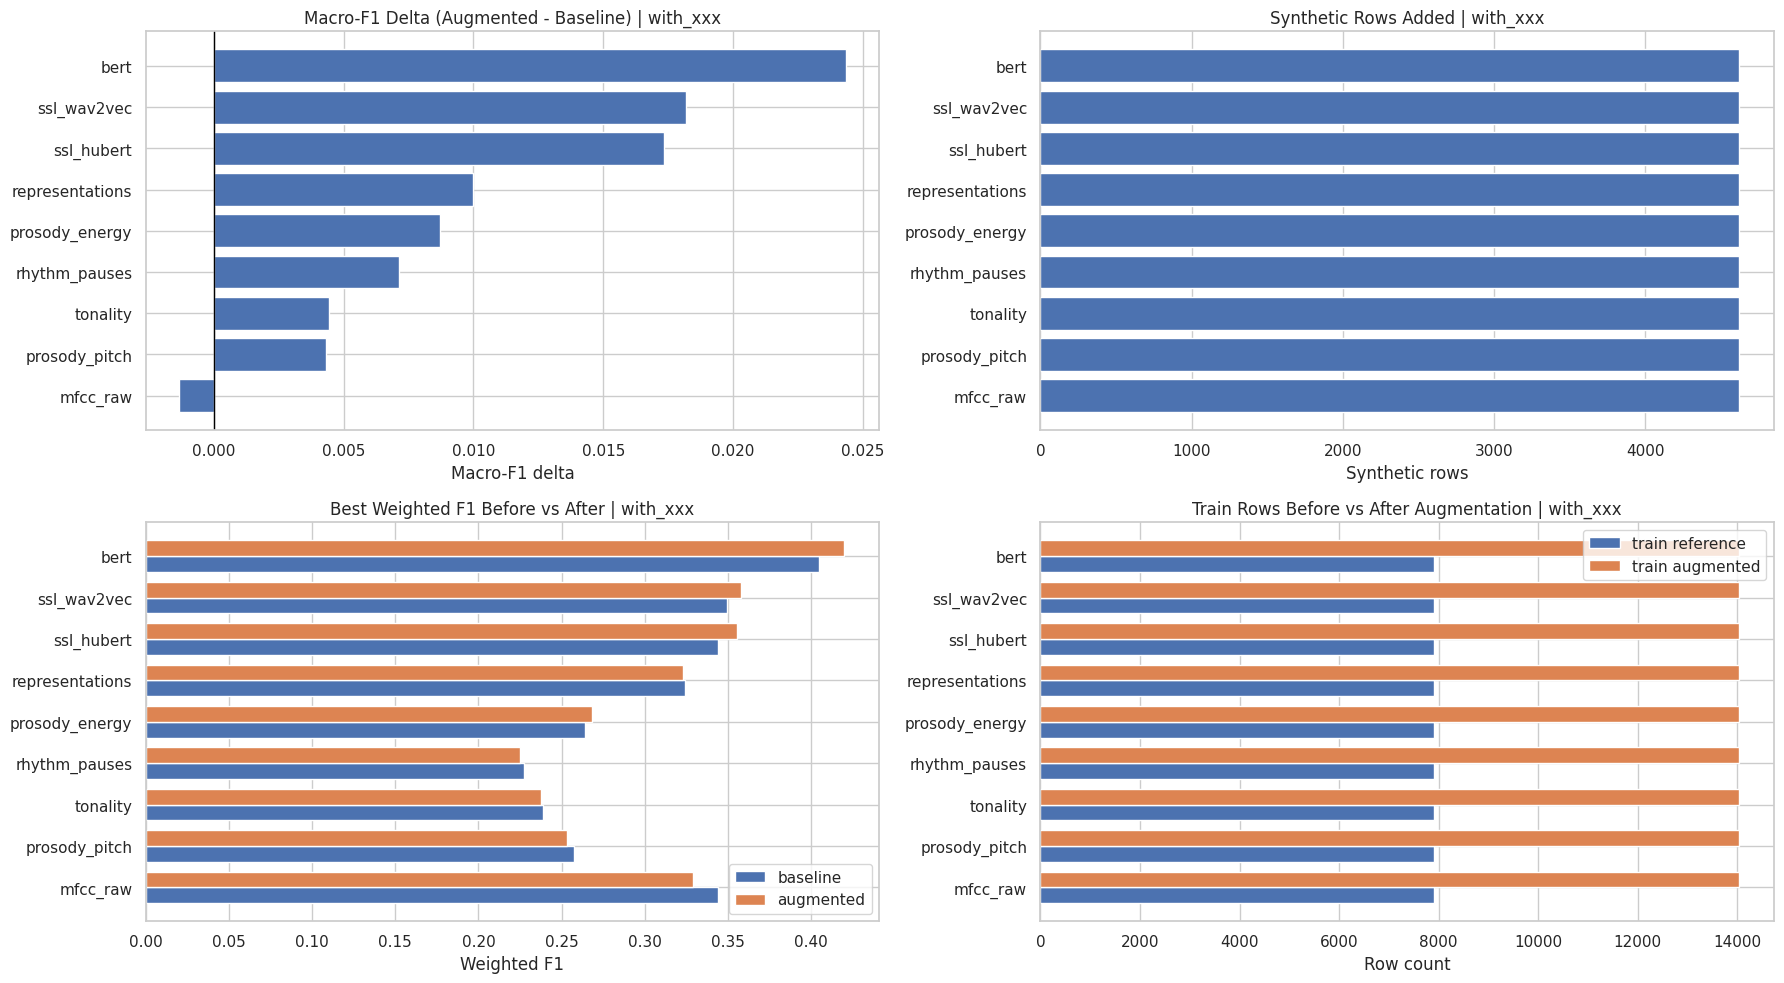

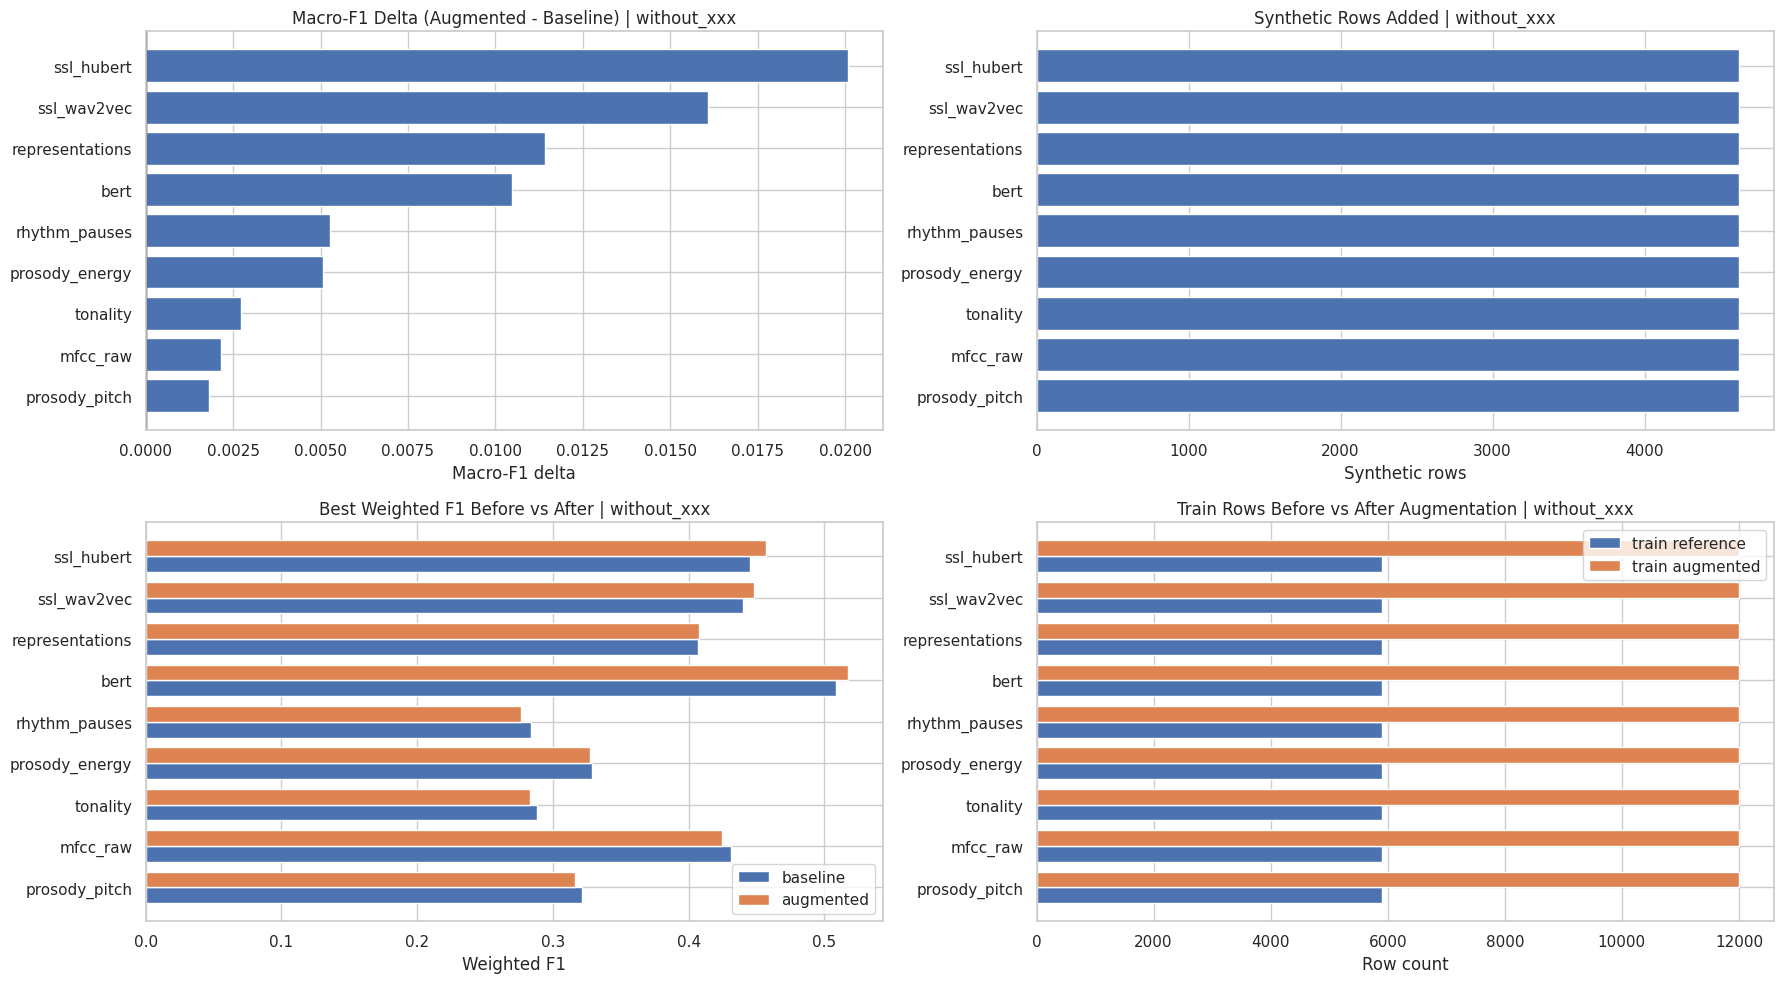

In [32]:
if not summary_df.empty:
    for group_name in summary_df['group'].unique():
        group_df = summary_df[summary_df['group'] == group_name].copy().sort_values('f1_macro_delta', ascending=True)
        fig, axes = plt.subplots(2, 2, figsize=(18, 10))

        axes[0, 0].barh(group_df['dataset_key'], group_df['f1_macro_delta'])
        axes[0, 0].axvline(0.0, color='black', linewidth=1)
        axes[0, 0].set_title(f'Macro-F1 Delta (Augmented - Baseline) | {group_name}')
        axes[0, 0].set_xlabel('Macro-F1 delta')

        axes[0, 1].barh(group_df['dataset_key'], group_df['synthetic_rows_added'])
        axes[0, 1].set_title(f'Synthetic Rows Added | {group_name}')
        axes[0, 1].set_xlabel('Synthetic rows')

        width = 0.38
        y_pos = np.arange(len(group_df))
        axes[1, 0].barh(y_pos - width / 2, group_df['baseline_f1_weighted'], height=width, label='baseline')
        axes[1, 0].barh(y_pos + width / 2, group_df['augmented_f1_weighted'], height=width, label='augmented')
        axes[1, 0].set_yticks(y_pos, group_df['dataset_key'])
        axes[1, 0].set_title(f'Best Weighted F1 Before vs After | {group_name}')
        axes[1, 0].set_xlabel('Weighted F1')
        axes[1, 0].legend()

        axes[1, 1].barh(y_pos - width / 2, group_df['train_rows_reference'], height=width, label='train reference')
        axes[1, 1].barh(y_pos + width / 2, group_df['train_rows_after_augmentation'], height=width, label='train augmented')
        axes[1, 1].set_yticks(y_pos, group_df['dataset_key'])
        axes[1, 1].set_title(f'Train Rows Before vs After Augmentation | {group_name}')
        axes[1, 1].set_xlabel('Row count')
        axes[1, 1].legend()

        plt.tight_layout()
        plt.show()
else:
    print('No augmentation artifact metadata found.')


In [33]:
if not model_delta_df.empty:
    for metric_col in ['accuracy_delta', 'f1_weighted_delta', 'f1_macro_delta']:
        pivot_df = model_delta_df.pivot_table(
            index='dataset_key',
            columns=['group', 'model'],
            values=metric_col,
            aggfunc='first',
        ).sort_index()
        fig, ax = plt.subplots(figsize=(max(12, 1.2 * len(pivot_df.columns)), max(6, 0.45 * len(pivot_df.index))))
        sns.heatmap(pivot_df, annot=True, fmt='.3f', cmap='coolwarm', center=0.0, ax=ax)
        ax.set_title(f'Model-level {metric_col} Heatmap')
        plt.tight_layout()
        plt.show()
else:
    print('No model delta table found.')


No model delta table found.


,group|with_xxx,dataset_key,rows_loaded|with_xxx,rows_after_filter|with_xxx,rows_used|with_xxx,train_rows_reference|with_xxx,test_rows_reference|with_xxx,train_rows_after_augmentation|with_xxx,synthetic_rows_added|with_xxx,feature_columns_used|with_xxx,...,augmented_f1_macro|without_xxx,artifact_dir|without_xxx,meta_path|without_xxx,accuracy_delta|without_xxx,precision_weighted_delta|without_xxx,recall_weighted_delta|without_xxx,f1_weighted_delta|without_xxx,f1_macro_delta|without_xxx,augmented_f1_macro_change_without_xxx_minus_with_xxx,augmentation_gain_change_without_xxx_minus_with_xxx
0,with_xxx,bert,9887,9887,9887,7909.6,1977.4,14032.6,4620,768,...,0.501941,/cluster/home/bekadb/Speech-Emotion-Recognitio...,/cluster/home/bekadb/Speech-Emotion-Recognitio...,0.007136,-0.003216,0.007136,0.008639,0.010461,0.093719,-0.013883
1,with_xxx,ssl_wav2vec,9887,9887,9887,7909.6,1977.4,14032.6,4620,1539,...,0.420140,/cluster/home/bekadb/Speech-Emotion-Recognitio...,/cluster/home/bekadb/Speech-Emotion-Recognitio...,0.001425,-0.008033,0.001425,0.007854,0.016069,0.081116,-0.002114
2,with_xxx,ssl_hubert,9887,9887,9887,7909.6,1977.4,14032.6,4620,1539,...,0.428726,/cluster/home/bekadb/Speech-Emotion-Recognitio...,/cluster/home/bekadb/Speech-Emotion-Recognitio...,0.004656,0.005484,0.004656,0.011794,0.020074,0.090402,0.002741
3,with_xxx,representations,9887,9887,9887,7909.6,1977.4,14032.6,4620,136,...,0.376776,/cluster/home/bekadb/Speech-Emotion-Recognitio...,/cluster/home/bekadb/Speech-Emotion-Recognitio...,-0.010113,-0.028919,-0.010113,0.000972,0.011411,0.070514,0.001431
4,with_xxx,prosody_energy,9887,9887,9887,7909.6,1977.4,14032.6,4620,8,...,0.301640,/cluster/home/bekadb/Speech-Emotion-Recognitio...,/cluster/home/bekadb/Speech-Emotion-Recognitio...,-0.010827,-0.008709,-0.010827,-0.001184,0.005068,0.055953,-0.003662
5,with_xxx,rhythm_pauses,9887,9887,9887,7909.6,1977.4,14032.6,4620,6,...,0.248977,/cluster/home/bekadb/Speech-Emotion-Recognitio...,/cluster/home/bekadb/Speech-Emotion-Recognitio...,-0.024324,-0.012975,-0.024324,-0.007105,0.005281,0.047001,-0.001858
6,with_xxx,tonality,9887,9887,9887,7909.6,1977.4,14032.6,4620,91,...,0.254932,/cluster/home/bekadb/Speech-Emotion-Recognitio...,/cluster/home/bekadb/Speech-Emotion-Recognitio...,-0.018695,-0.020482,-0.018695,-0.005021,0.002720,0.047717,-0.001704
7,with_xxx,prosody_pitch,9887,9887,9887,7909.6,1977.4,14032.6,4620,11,...,0.287027,/cluster/home/bekadb/Speech-Emotion-Recognitio...,/cluster/home/bekadb/Speech-Emotion-Recognitio...,-0.010145,-0.011412,-0.010145,-0.005344,0.001822,0.055675,-0.002493
8,with_xxx,mfcc_raw,9887,9887,9887,7909.6,1977.4,14032.6,4620,1150,...,0.399186,/cluster/home/bekadb/Speech-Emotion-Recognitio...,/cluster/home/bekadb/Speech-Emotion-Recognitio...,-0.010918,-0.012714,-0.010918,-0.006841,0.002154,0.075816,0.003496


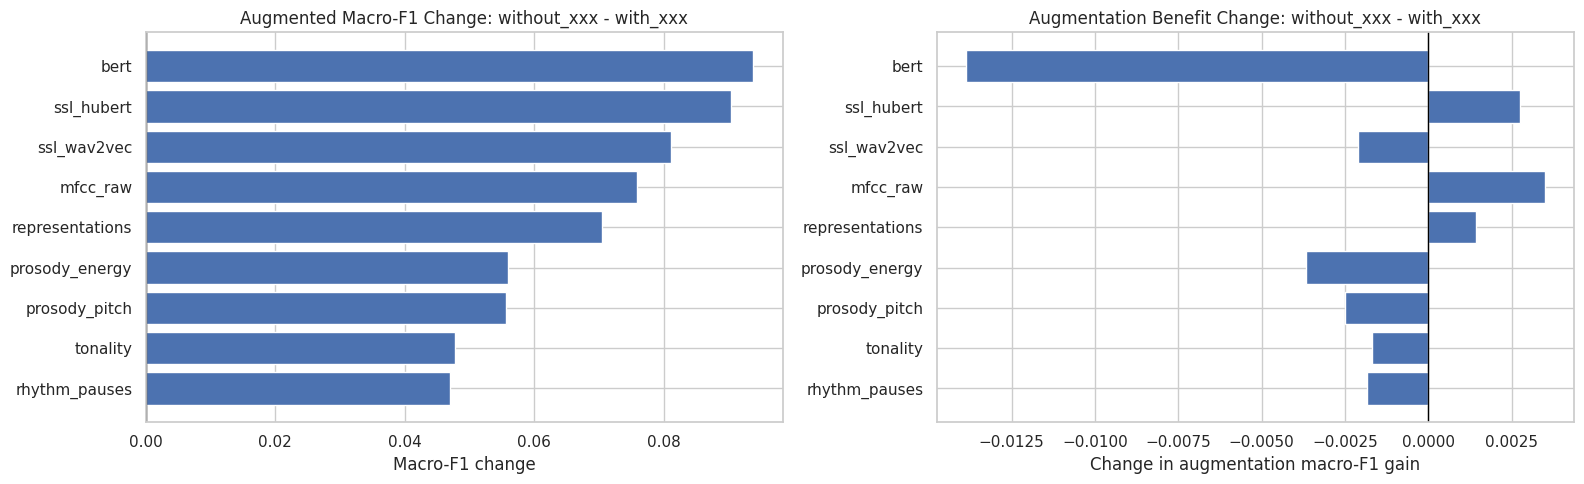

Saved comparison CSV: /cluster/home/bekadb/Speech-Emotion-Recognition/feature_augmentation/mean_std_oversampling/artifacts/augmentation_xxx_artifact_comparison.csv


In [34]:
required_groups = {'with_xxx', 'without_xxx'}
available_groups = set(summary_df['group'].unique()) if not summary_df.empty else set()

if not required_groups.issubset(available_groups):
    print('Configured artifact groups do not yet include both `with_xxx` and `without_xxx`.')
else:
    xxx_compare_df = build_pairwise_comparison(summary_df, 'with_xxx', 'without_xxx')
    display(xxx_compare_df)

    plot_df = xxx_compare_df.sort_values('augmented_f1_macro_change_without_xxx_minus_with_xxx', ascending=True)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].barh(plot_df['dataset_key'], plot_df['augmented_f1_macro_change_without_xxx_minus_with_xxx'])
    axes[0].axvline(0.0, color='black', linewidth=1)
    axes[0].set_title('Augmented Macro-F1 Change: without_xxx - with_xxx')
    axes[0].set_xlabel('Macro-F1 change')

    axes[1].barh(plot_df['dataset_key'], plot_df['augmentation_gain_change_without_xxx_minus_with_xxx'])
    axes[1].axvline(0.0, color='black', linewidth=1)
    axes[1].set_title('Augmentation Benefit Change: without_xxx - with_xxx')
    axes[1].set_xlabel('Change in augmentation macro-F1 gain')

    plt.tight_layout()
    plt.show()

    if SAVE_COMPARISON_CSV:
        out_path = DEFAULT_ARTIFACT_DIR / 'augmentation_xxx_artifact_comparison.csv'
        xxx_compare_df.to_csv(out_path, index=False)
        print(f'Saved comparison CSV: {out_path}')


Focused dataset: bert | group=with_xxx


,stage,emotion,class_count
0,raw_loaded,ang,1103
1,raw_loaded,exc,1041
2,raw_loaded,fru,1849
3,raw_loaded,hap,595
4,raw_loaded,neu,1708
5,raw_loaded,sad,1084
6,raw_loaded,xxx,2507
7,filtered,ang,1103
8,filtered,exc,1041
9,filtered,fru,1849


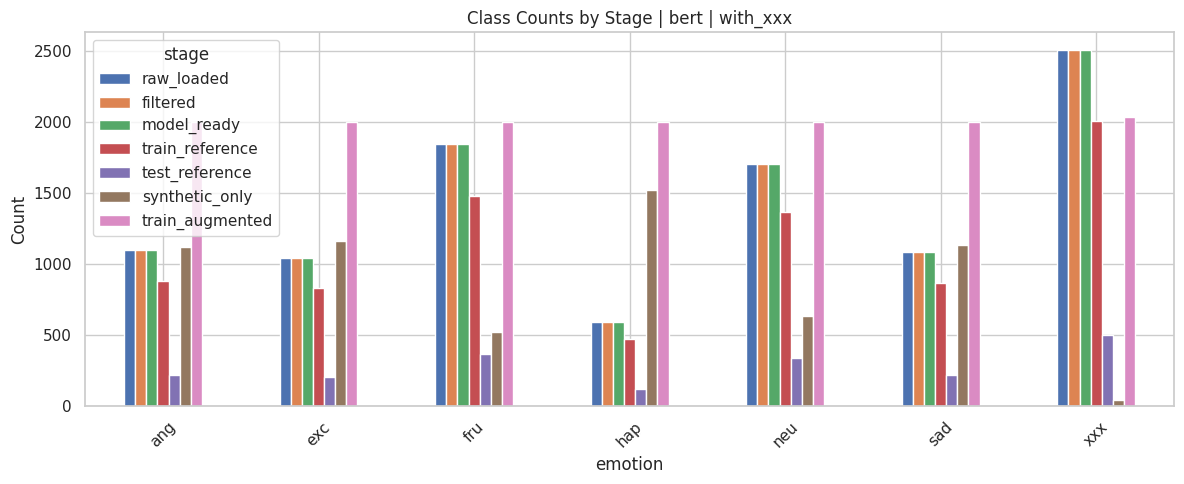

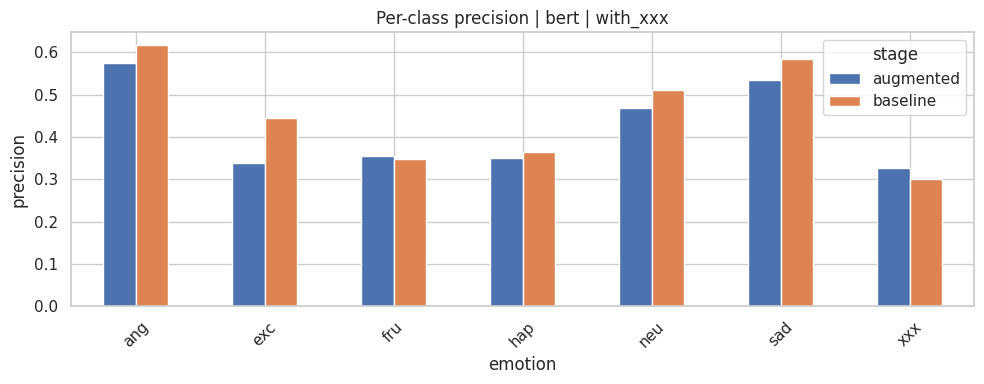

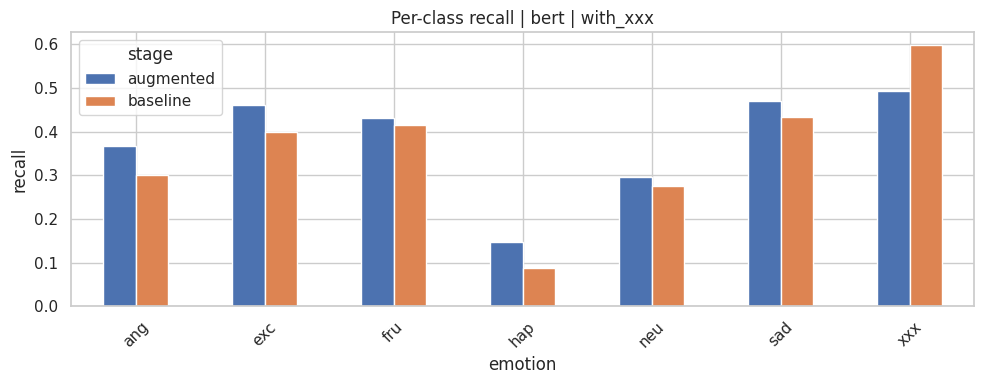

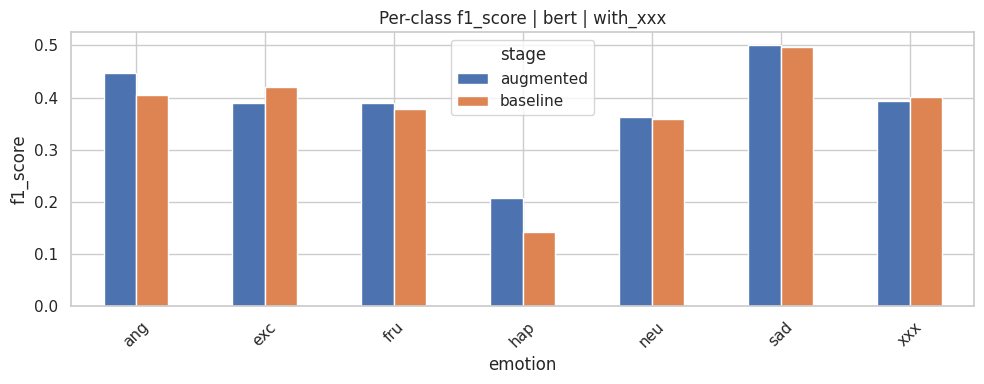

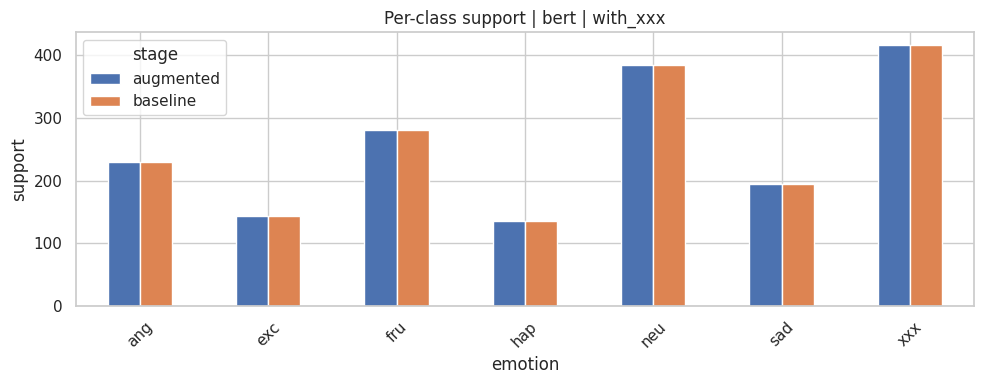

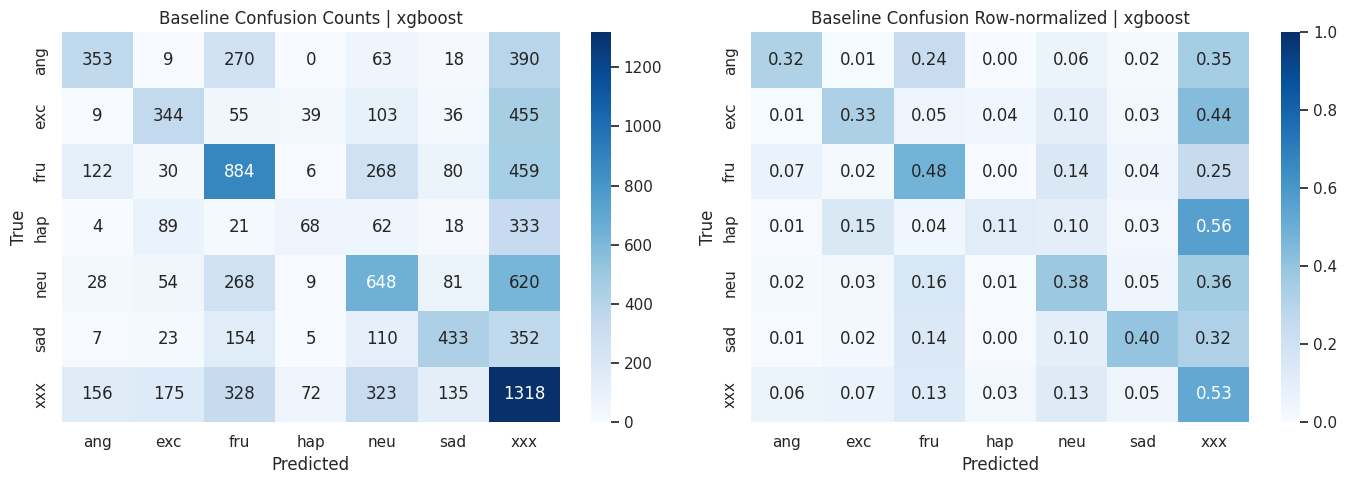

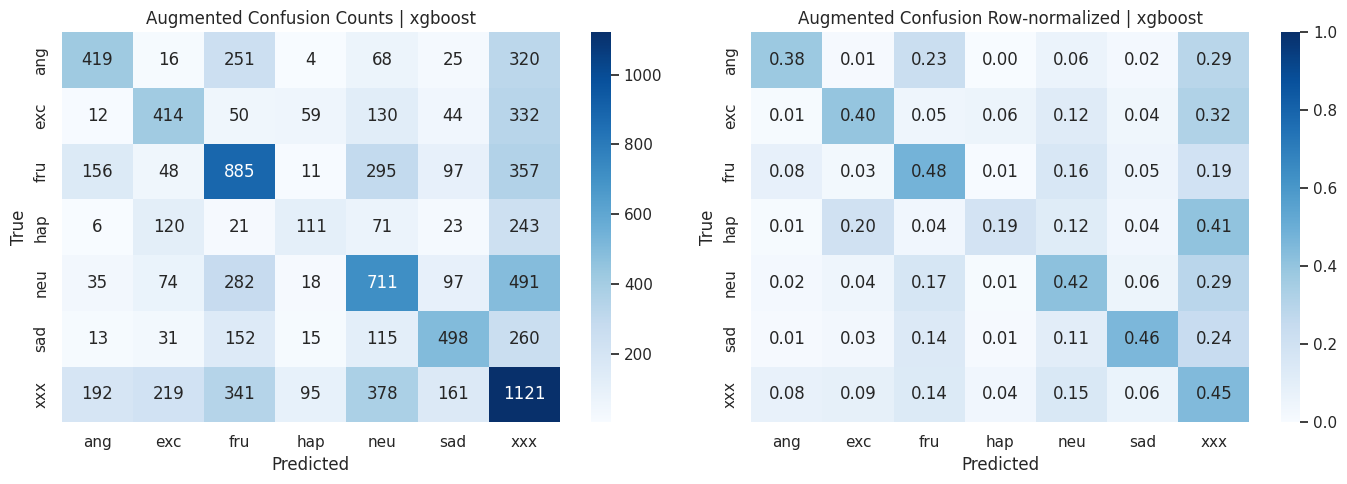

In [35]:
if summary_df.empty:
    print('No artifact data to inspect.')
else:
    selected_dataset = FOCUS_DATASET or summary_df.iloc[0]['dataset_key']
    selected_group = FOCUS_GROUP or summary_df[summary_df['dataset_key'] == selected_dataset].iloc[0]['group']

    focus_meta = load_artifact_meta(selected_dataset, selected_group)
    focus_counts_df = load_stage_counts(selected_dataset, selected_group)
    focus_kind_df = load_synthetic_kind_counts(selected_dataset, selected_group)
    focus_report_df = load_reports(selected_dataset, selected_group)
    focus_conf_df = load_confusions(selected_dataset, selected_group)

    print(f'Focused dataset: {selected_dataset} | group={selected_group}')
    display(focus_counts_df)

    stage_order = ['raw_loaded', 'filtered', 'model_ready', 'train_reference', 'test_reference', 'synthetic_only', 'train_augmented']
    stage_plot_df = focus_counts_df[focus_counts_df['stage'].isin(stage_order)].copy()
    stage_pivot = (
        stage_plot_df
        .pivot(index=focus_meta.get('target_col', 'emotion'), columns='stage', values='class_count')
        .fillna(0)
        .reindex(columns=stage_order)
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    stage_pivot.plot(kind='bar', ax=ax)
    ax.set_title(f'Class Counts by Stage | {selected_dataset} | {selected_group}')
    ax.set_xlabel(focus_meta.get('target_col', 'emotion'))
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    if not focus_kind_df.empty:
        kind_pivot = focus_kind_df.pivot(index=focus_meta.get('target_col', 'emotion'), columns='synthetic_kind', values='count').fillna(0)
        fig, ax = plt.subplots(figsize=(10, 5))
        kind_pivot.plot(kind='bar', stacked=True, ax=ax)
        ax.set_title(f'Synthetic Kind Mix by Emotion | {selected_dataset} | {selected_group}')
        ax.set_xlabel(focus_meta.get('target_col', 'emotion'))
        ax.set_ylabel('Synthetic rows')
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.show()

    best_models = [
        focus_meta.get('best_baseline_model'),
        focus_meta.get('best_augmented_model'),
    ]
    report_focus_df = focus_report_df[
        (focus_report_df['label_type'] == 'class')
        & (focus_report_df['model'].isin(best_models))
    ].copy()

    if not report_focus_df.empty:
        for metric_name in ['precision', 'recall', 'f1_score', 'support']:
            plot_df = report_focus_df.pivot_table(
                index='label',
                columns='stage',
                values=metric_name,
                aggfunc='first',
            ).fillna(0.0)
            fig, ax = plt.subplots(figsize=(10, 4))
            plot_df.plot(kind='bar', ax=ax)
            ax.set_title(f'Per-class {metric_name} | {selected_dataset} | {selected_group}')
            ax.set_xlabel(focus_meta.get('target_col', 'emotion'))
            ax.set_ylabel(metric_name)
            ax.tick_params(axis='x', rotation=45)
            plt.tight_layout()
            plt.show()

    label_order = [str(label) for label in focus_meta.get('classes', [])]
    for stage_name, model_name in [('baseline', focus_meta.get('best_baseline_model')), ('augmented', focus_meta.get('best_augmented_model'))]:
        stage_conf_df = focus_conf_df[
            (focus_conf_df['stage'] == stage_name)
            & (focus_conf_df['model'] == model_name)
        ].copy()
        if stage_conf_df.empty:
            continue
        pivot_df = stage_conf_df.pivot_table(
            index='true_label',
            columns='predicted_label',
            values='count',
            aggfunc='sum',
        ).fillna(0)
        pivot_df = pivot_df.reindex(index=label_order, columns=label_order, fill_value=0)
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        sns.heatmap(pivot_df, annot=True, fmt='.0f', cmap='Blues', ax=axes[0])
        axes[0].set_title(f'{stage_name.title()} Confusion Counts | {model_name}')
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('True')

        norm_df = pivot_df.div(pivot_df.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
        sns.heatmap(norm_df, annot=True, fmt='.2f', cmap='Blues', vmin=0.0, vmax=1.0, ax=axes[1])
        axes[1].set_title(f'{stage_name.title()} Confusion Row-normalized | {model_name}')
        axes[1].set_xlabel('Predicted')
        axes[1].set_ylabel('True')
        plt.tight_layout()
        plt.show()
